# AtlasNet — from scratch on Mac (MPS)

Track 1 · Stages 2→3 from actionable.md  

**Stage 2 (now):** autoencoder — one learned latent code per shape, AtlasNet decoder, Chamfer loss.  
Uses the 221 chair OBJs in `data/pix3d/model/` directly — no annotation JSON needed.

**Stage 3 (later):** swap the embedding table for a ResNet18 image encoder once  
`pix3d.json` is available (maps image numbers → model folders).

```
Stage 2 (autoencoder)          Stage 3 (image-conditioned)
─────────────────────          ──────────────────────────
shape_id  ──► Embedding        image ──► ResNet18
                 │                           │
                 z (1024,)                   z (1024,)
                 │                           │
            AtlasDecoder               AtlasDecoder
                 │                           │
           point cloud                 point cloud
```

Dataset layout expected at `PIX3D_ROOT`:
```
data/pix3d/
  img/    0001.png … 3839.png   ← RGB chair photos
  mesh/   0001.png … 3839.png   ← silhouette masks (paired with img/)
  model/  IKEA_BERNHARD/model.obj
          SS_001/model.obj
          …  (221 models total)
  pix3d.json                    ← NOT present yet; needed for Stage 3
```

In [1]:
import torch
import torch.nn as nn
import torchvision.models as tvm
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import json
from pathlib import Path
import time

DEVICE = (
    torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
PIX3D_ROOT = Path('../data/pix3d')

print('device   :', DEVICE)
print('torch    :', torch.__version__)
print('pix3d    :', PIX3D_ROOT.resolve())
print('models   :', len(list((PIX3D_ROOT / 'model').glob('*/*/model.obj'))), 'OBJs found')

device   : mps
torch    : 2.11.0
pix3d    : /Users/rx0/Desktop/FoundationOfAIML/2/generational-bullshit/data/pix3d
models   : 216 OBJs found


## 1  Chamfer Distance

In [2]:
def chamfer_distance(p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
    """
    p: (B, N, 3)  predicted
    q: (B, M, 3)  ground truth
    Returns scalar mean Chamfer loss.
    Memory note: (B, N, M) distance matrix — keep B*N*M < ~100M on MPS.
    """
    diff  = p.unsqueeze(2) - q.unsqueeze(1)   # (B, N, M, 3)
    dist2 = (diff ** 2).sum(-1)               # (B, N, M)
    return dist2.min(2).values.mean() + dist2.min(1).values.mean()


_a = torch.randn(2, 200, 3, device=DEVICE)
_b = torch.randn(2, 200, 3, device=DEVICE)
print('Chamfer smoke:', chamfer_distance(_a, _b).item())

Chamfer smoke: 0.4631774127483368


## 2  AtlasNet decoder + two encoder heads

In [3]:
def _patch_mlp(latent_dim: int, hidden: int = 512) -> nn.Sequential:
    """Maps [u∈S²(3) ; z(latent_dim)] → point∈ℝ³."""
    return nn.Sequential(
        nn.Linear(latent_dim + 3, hidden), nn.ReLU(True),
        nn.Linear(hidden, hidden),         nn.ReLU(True),
        nn.Linear(hidden, hidden),         nn.ReLU(True),
        nn.Linear(hidden, 3),              nn.Tanh(),
    )


class AtlasDecoder(nn.Module):
    """Shared decoder: K patch MLPs mapping latent code → point cloud."""
    def __init__(self, latent_dim=1024, n_patches=25, points_per_patch=100, hidden=512):
        super().__init__()
        self.n_patches        = n_patches
        self.points_per_patch = points_per_patch
        self.patches = nn.ModuleList(
            [_patch_mlp(latent_dim, hidden) for _ in range(n_patches)]
        )

    def forward(self, z: torch.Tensor, M: int | None = None) -> torch.Tensor:
        """z: (B, latent_dim)  →  (B, n_patches*M, 3)"""
        M = M or self.points_per_patch
        B = z.size(0)
        clouds = []
        for mlp in self.patches:
            u   = nn.functional.normalize(torch.randn(B, M, 3, device=z.device), dim=-1)
            inp = torch.cat([u, z.unsqueeze(1).expand(-1, M, -1)], dim=-1)
            clouds.append(mlp(inp))
        return torch.cat(clouds, dim=1)


# ── Stage 2: autoencoder (embedding table, no image needed) ──────────────────
class AtlasNetAE(nn.Module):
    """One learned latent code per shape; decoder reconstructs from it."""
    def __init__(self, n_shapes: int, latent_dim=1024, **decoder_kwargs):
        super().__init__()
        self.embedding = nn.Embedding(n_shapes, latent_dim)
        nn.init.normal_(self.embedding.weight, std=0.1)
        self.decoder = AtlasDecoder(latent_dim=latent_dim, **decoder_kwargs)

    def forward(self, shape_ids: torch.Tensor) -> torch.Tensor:
        """shape_ids: (B,) int64"""
        return self.decoder(self.embedding(shape_ids))


# ── Stage 3: image-conditioned (ResNet18 encoder) ───────────────────────────
class AtlasNetImg(nn.Module):
    """ResNet18 image encoder + same AtlasDecoder. Requires pix3d.json."""
    def __init__(self, latent_dim=1024, **decoder_kwargs):
        super().__init__()
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Linear(backbone.fc.in_features, latent_dim)
        self.encoder = backbone
        self.decoder = AtlasDecoder(latent_dim=latent_dim, **decoder_kwargs)

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(img))


# --- smoke test ---
_ae  = AtlasNetAE(n_shapes=221, n_patches=5, points_per_patch=50).to(DEVICE)
_ids = torch.zeros(2, dtype=torch.long, device=DEVICE)
_out = _ae(_ids)
print('AE output :', _out.shape)   # (2, 250, 3)
print('AE params :', sum(p.numel() for p in _ae.parameters()) // 1000, 'k')
del _ae, _ids, _out

AE output : torch.Size([2, 250, 3])
AE params : 5492 k


## 3  Dataset — 221 OBJ models

No annotation JSON needed. Each OBJ is one shape; we sample its vertices as a point cloud.

In [4]:
def load_obj_pointcloud(obj_path: Path, n_points: int = 2500) -> torch.Tensor:
    """Read vertices from .obj, sample n_points, normalise to [-1,1]³."""
    verts = []
    with open(obj_path) as f:
        for line in f:
            if line.startswith('v '):
                parts = line.split()
                verts.append([float(parts[1]), float(parts[2]), float(parts[3])])
    v = torch.tensor(verts, dtype=torch.float32)
    v -= v.mean(0)
    scale = v.abs().max()
    if scale > 0:
        v /= scale
    N = v.size(0)
    idx = torch.randperm(N)[:n_points] if N >= n_points else torch.randint(N, (n_points,))
    return v[idx]


class Pix3DModels(Dataset):
    """
    Stage 2 dataset: (shape_id, point_cloud) pairs from the OBJ models.
    shape_id is the index into the sorted model list — used by AtlasNetAE's
    embedding table.
    """
    def __init__(self, root: Path, split: str = 'train', n_points: int = 2500,
                 val_frac: float = 0.1, seed: int = 42):
        self.root     = root
        self.n_points = n_points

        all_objs = sorted((root / 'model').glob('*/*/model.obj'))
        assert all_objs, f'No model.obj files found under {root}/model/'

        rng = np.random.default_rng(seed)
        order = rng.permutation(len(all_objs))
        n_val = max(1, int(len(all_objs) * val_frac))

        val_idx  = set(order[:n_val].tolist())
        if split == 'train':
            self.indices = [i for i in range(len(all_objs)) if i not in val_idx]
        else:
            self.indices = [i for i in range(len(all_objs)) if i in val_idx]

        self.all_objs = all_objs   # keep full list so shape_id == global index
        print(f'Pix3DModels [{split}]: {len(self.indices)} shapes')

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        shape_id = self.indices[idx]
        pts      = load_obj_pointcloud(self.all_objs[shape_id], self.n_points)
        return torch.tensor(shape_id, dtype=torch.long), pts


N_GT_POINTS = 2500

train_ds = Pix3DModels(PIX3D_ROOT, 'train', n_points=N_GT_POINTS)
val_ds   = Pix3DModels(PIX3D_ROOT, 'val',   n_points=N_GT_POINTS)
N_SHAPES = len(train_ds.all_objs)
print(f'Total shapes in embedding table: {N_SHAPES}')

sid, pts = train_ds[0]
print(f'shape_id={sid.item()}  pts={pts.shape}  range=[{pts.min():.2f}, {pts.max():.2f}]')

Pix3DModels [train]: 195 shapes
Pix3DModels [val]: 21 shapes
Total shapes in embedding table: 216
shape_id=0  pts=torch.Size([2500, 3])  range=[-0.53, 1.00]


## 4  DataLoader

`num_workers=0` — avoids MPS fork issues on macOS.

In [5]:
BATCH_SIZE = 8

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('train batches:', len(train_loader), '  val batches:', len(val_loader))

train batches: 25   val batches: 3


## 5  Training — Stage 2 autoencoder

In [6]:
N_PATCHES        = 25
POINTS_PER_PATCH = 100     # 25 * 100 = 2500 output points == N_GT_POINTS
LATENT_DIM       = 1024
LR               = 1e-3
N_EPOCHS         = 200     # small dataset — needs more epochs to overfit each shape
SAVE_PATH        = Path('atlasnet_ae.pt')

model = AtlasNetAE(
    n_shapes         = N_SHAPES,
    latent_dim       = LATENT_DIM,
    n_patches        = N_PATCHES,
    points_per_patch = POINTS_PER_PATCH,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

train_losses, val_losses = [], []


def run_epoch(loader, train: bool) -> float:
    model.train(train)
    total = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for shape_ids, pts_gt in loader:
            shape_ids = shape_ids.to(DEVICE)
            pts_gt    = pts_gt.to(DEVICE)
            pts_pred  = model(shape_ids)            # (B, 2500, 3)
            loss      = chamfer_distance(pts_pred, pts_gt)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item()
    return total / len(loader)


best_val = float('inf')
for epoch in range(1, N_EPOCHS + 1):
    t0         = time.time()
    tl         = run_epoch(train_loader, True)
    vl         = run_epoch(val_loader,   False)
    scheduler.step()
    train_losses.append(tl)
    val_losses.append(vl)

    if epoch % 10 == 0 or epoch == 1:
        print(f'epoch {epoch:4d}/{N_EPOCHS}  '
              f'train={tl:.4f}  val={vl:.4f}  ({time.time()-t0:.1f}s)')

    if vl < best_val:
        best_val = vl
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'n_shapes': N_SHAPES, 'val_loss': vl}, SAVE_PATH)

print(f'Done. Best val Chamfer: {best_val:.4f}')

epoch    1/200  train=0.1283  val=0.0727  (13.2s)
epoch   10/200  train=0.0089  val=0.0525  (12.1s)
epoch   20/200  train=0.0058  val=0.0517  (12.1s)
epoch   30/200  train=0.0051  val=0.0525  (12.1s)
epoch   40/200  train=0.0041  val=0.0523  (12.2s)
epoch   50/200  train=0.0036  val=0.0520  (12.1s)
epoch   60/200  train=0.0029  val=0.0520  (12.5s)
epoch   70/200  train=0.0026  val=0.0526  (12.1s)
epoch   80/200  train=0.0024  val=0.0533  (12.1s)
epoch   90/200  train=0.0027  val=0.0524  (15.2s)
epoch  100/200  train=0.0021  val=0.0529  (12.2s)
epoch  110/200  train=0.0019  val=0.0533  (12.1s)
epoch  120/200  train=0.0018  val=0.0529  (12.1s)
epoch  130/200  train=0.0017  val=0.0530  (12.1s)
epoch  140/200  train=0.0017  val=0.0531  (12.3s)
epoch  150/200  train=0.0016  val=0.0528  (12.1s)
epoch  160/200  train=0.0016  val=0.0528  (12.4s)
epoch  170/200  train=0.0015  val=0.0527  (12.9s)
epoch  180/200  train=0.0015  val=0.0530  (12.9s)
epoch  190/200  train=0.0015  val=0.0532  (12.2s)


## 6  Loss curves

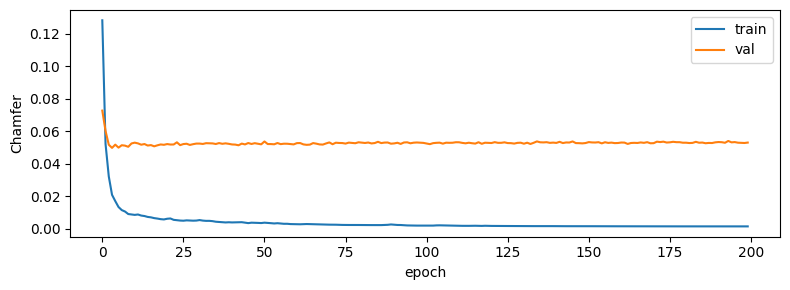

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('epoch')
plt.ylabel('Chamfer')
plt.legend()
plt.tight_layout()
plt.show()

## 7  Visualise — predicted vs GT point cloud

epoch 4  val Chamfer 0.0498


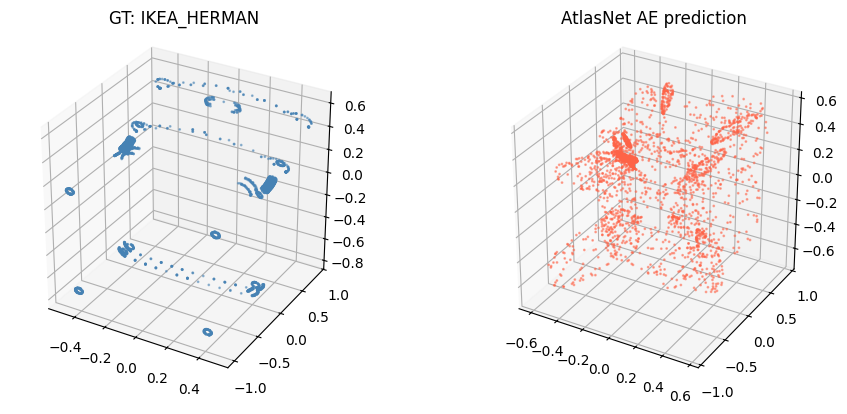

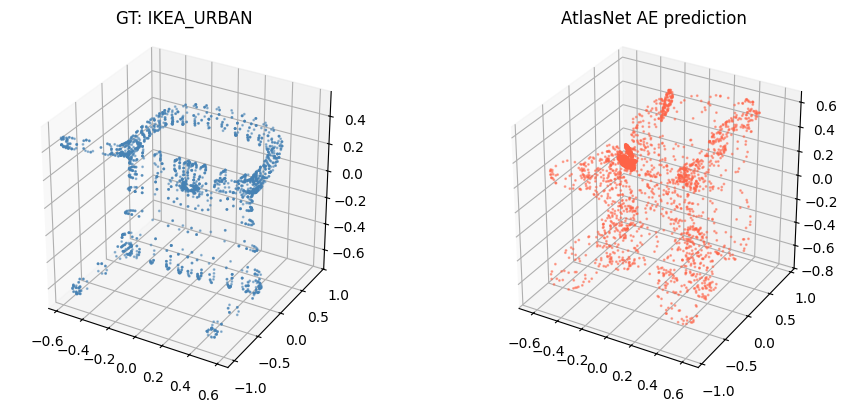

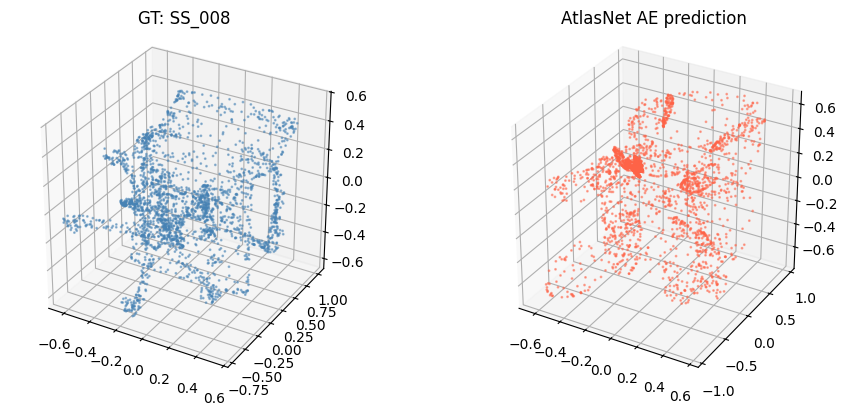

In [8]:
from mpl_toolkits.mplot3d import Axes3D   # noqa

ckpt = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"epoch {ckpt['epoch']}  val Chamfer {ckpt['val_loss']:.4f}")

shape_ids, pts_gt = next(iter(val_loader))
with torch.no_grad():
    pts_pred = model(shape_ids.to(DEVICE)).cpu()

for i in range(min(3, len(shape_ids))):
    fig = plt.figure(figsize=(10, 4))
    name = train_ds.all_objs[shape_ids[i].item()].parent.name

    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(*pts_gt[i].T,   s=1, c='steelblue', alpha=0.5)
    ax.set_title(f'GT: {name}')
    ax.set_box_aspect([1,1,1])

    ax = fig.add_subplot(122, projection='3d')
    ax.scatter(*pts_pred[i].T, s=1, c='tomato',    alpha=0.5)
    ax.set_title('AtlasNet AE prediction')
    ax.set_box_aspect([1,1,1])

    plt.tight_layout()
    plt.show()

## 8  Stage 3 — image-conditioned dataset

Replaces the embedding table with a ResNet18 that reads the chair photo.
Split is by *model* (not photo) so the val set has unseen chair shapes.

In [9]:
N_GT_POINTS = 2500
BATCH_SIZE  = 8

IMG_TRANSFORMS = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class Pix3DChairs(Dataset):
    """(image, point_cloud) pairs — requires pix3d.json."""
    def __init__(self, root, split='train', n_points=2500, transforms=None):
        with open(root / 'pix3d.json') as f:
            meta = json.load(f)
        chairs = [m for m in meta
                  if m['category'] == 'chair'
                  and not m.get('truncated') and not m.get('occluded')]
        model_ids = sorted({m['model'] for m in chairs})
        rng = np.random.default_rng(42)
        rng.shuffle(model_ids)
        val_ids = set(model_ids[:max(1, len(model_ids)//10)])
        self.samples = [m for m in chairs
                        if (m['model'] not in val_ids) == (split == 'train')]
        self.root, self.n_points, self.transforms = root, n_points, transforms
        print(f'Pix3DChairs [{split}]: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        m   = self.samples[idx]
        img = Image.open(self.root / m['img']).convert('RGB')
        if self.transforms: img = self.transforms(img)
        pts = load_obj_pointcloud(self.root / m['model'], self.n_points)
        return img, pts


img_train_ds = Pix3DChairs(PIX3D_ROOT, 'train', n_points=N_GT_POINTS, transforms=IMG_TRANSFORMS)
img_val_ds   = Pix3DChairs(PIX3D_ROOT, 'val',   n_points=N_GT_POINTS, transforms=IMG_TRANSFORMS)

img_train_loader = DataLoader(img_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
img_val_loader   = DataLoader(img_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

img, pts = img_train_ds[0]
print(f'img: {img.shape}  pts: {pts.shape}')

Pix3DChairs [train]: 2596 samples
Pix3DChairs [val]: 468 samples
img: torch.Size([3, 224, 224])  pts: torch.Size([2500, 3])


## 9  Training — Stage 3 (transfer decoder from AE)

Loads Stage 2 decoder weights into `AtlasNetImg.decoder` so the network
starts with chair geometry already baked in — only the ResNet18 trains from scratch.
Decoder is frozen for the first 20 epochs then unfrozen for joint fine-tuning.

epoch    9/100  train=0.0194  val=0.0479  (219.5s)


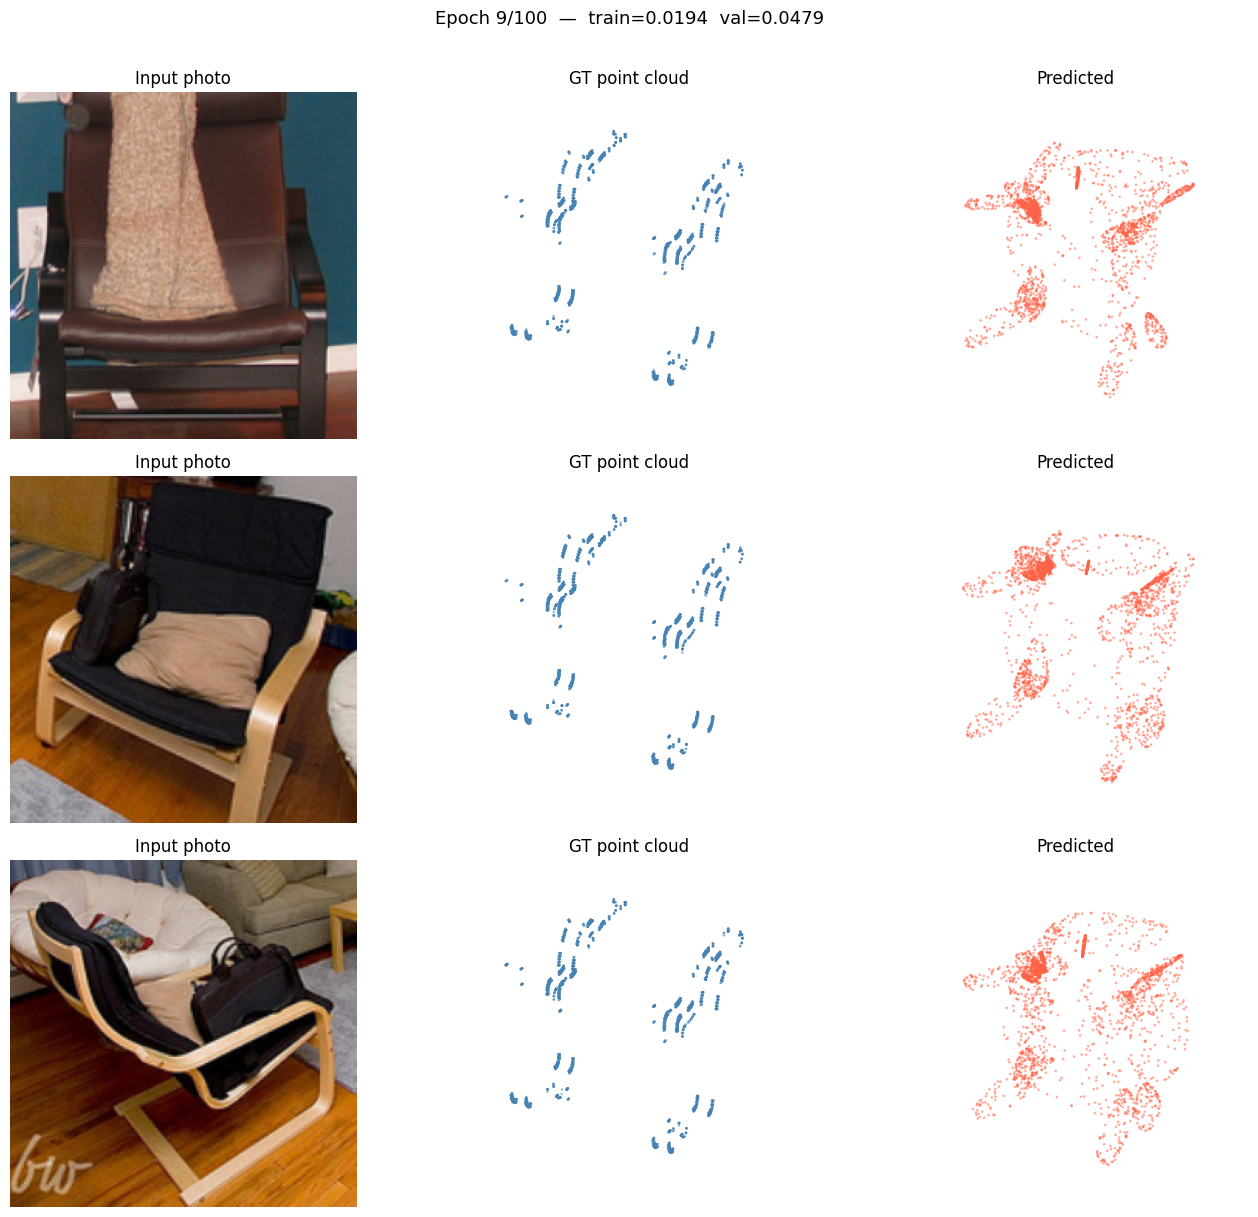

KeyboardInterrupt: 

In [10]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

AE_CKPT_PATH     = Path('atlasnet_ae.pt')
IMG_SAVE_PATH    = Path('atlasnet_img.pt')
LATENT_DIM       = 1024
N_PATCHES        = 25
POINTS_PER_PATCH = 100
FREEZE_EPOCHS    = 20
IMG_EPOCHS       = 100
IMG_LR           = 3e-4

_DENORM_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_DENORM_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img_model = AtlasNetImg(
    latent_dim       = LATENT_DIM,
    n_patches        = N_PATCHES,
    points_per_patch = POINTS_PER_PATCH,
).to(DEVICE)

ae_ckpt  = torch.load(AE_CKPT_PATH, map_location=DEVICE, weights_only=True)
ae_state = {k.removeprefix('decoder.'): v
            for k, v in ae_ckpt['model'].items() if k.startswith('decoder.')}
img_model.decoder.load_state_dict(ae_state)
print(f'Decoder transferred from {AE_CKPT_PATH}  '
      f'(AE epoch {ae_ckpt["epoch"]}, val={ae_ckpt["val_loss"]:.4f})')

img_optimizer = torch.optim.Adam(img_model.parameters(), lr=IMG_LR)
img_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(img_optimizer, T_max=IMG_EPOCHS)

img_train_losses, img_val_losses = [], []

# fix a single val batch for consistent epoch-to-epoch comparison
_fixed_imgs, _fixed_pts_gt = next(iter(img_val_loader))


def run_img_epoch(loader, train: bool) -> float:
    img_model.train(train)
    total = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, pts_gt in loader:
            imgs   = imgs.to(DEVICE)
            pts_gt = pts_gt.to(DEVICE)
            pts_pred = img_model(imgs)
            loss = chamfer_distance(pts_pred, pts_gt)
            if train:
                img_optimizer.zero_grad()
                loss.backward()
                img_optimizer.step()
            total += loss.item()
    return total / len(loader)


def plot_epoch(epoch, train_loss, val_loss):
    with torch.no_grad():
        pts_pred = img_model(_fixed_imgs.to(DEVICE)).cpu()

    n_show = min(3, len(_fixed_imgs))
    fig = plt.figure(figsize=(14, 4 * n_show))
    fig.suptitle(f'Epoch {epoch}/{IMG_EPOCHS}  —  train={train_loss:.4f}  val={val_loss:.4f}',
                 fontsize=13, y=1.01)

    for i in range(n_show):
        photo = (_fixed_imgs[i] * _DENORM_STD + _DENORM_MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

        ax = fig.add_subplot(n_show, 3, i * 3 + 1)
        ax.imshow(photo)
        ax.set_title('Input photo')
        ax.axis('off')

        ax = fig.add_subplot(n_show, 3, i * 3 + 2, projection='3d')
        ax.scatter(*_fixed_pts_gt[i].T, s=1, c='steelblue', alpha=0.4)
        ax.set_title('GT point cloud')
        ax.set_box_aspect([1, 1, 1])
        ax.set_axis_off()

        ax = fig.add_subplot(n_show, 3, i * 3 + 3, projection='3d')
        ax.scatter(*pts_pred[i].T, s=1, c='tomato', alpha=0.4)
        ax.set_title('Predicted')
        ax.set_box_aspect([1, 1, 1])
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()


best_img_val = float('inf')
for epoch in range(1, IMG_EPOCHS + 1):
    if epoch == 1:
        for p in img_model.decoder.parameters(): p.requires_grad_(False)
        print(f'Decoder frozen for first {FREEZE_EPOCHS} epochs')
    elif epoch == FREEZE_EPOCHS + 1:
        for p in img_model.decoder.parameters(): p.requires_grad_(True)
        print(f'Decoder unfrozen at epoch {epoch}')

    t0 = time.time()
    tl = run_img_epoch(img_train_loader, True)
    vl = run_img_epoch(img_val_loader,   False)
    img_scheduler.step()
    img_train_losses.append(tl)
    img_val_losses.append(vl)

    saved = ''
    if vl < best_img_val:
        best_img_val = vl
        torch.save({'epoch': epoch, 'model': img_model.state_dict(),
                    'val_loss': vl}, IMG_SAVE_PATH)
        saved = '  ✓ saved'

    clear_output(wait=True)
    print(f'epoch {epoch:4d}/{IMG_EPOCHS}  '
          f'train={tl:.4f}  val={vl:.4f}  ({time.time()-t0:.1f}s){saved}')
    plot_epoch(epoch, tl, vl)

print(f'Done. Best val Chamfer: {best_img_val:.4f}')

## 10  Loss curves — Stage 3

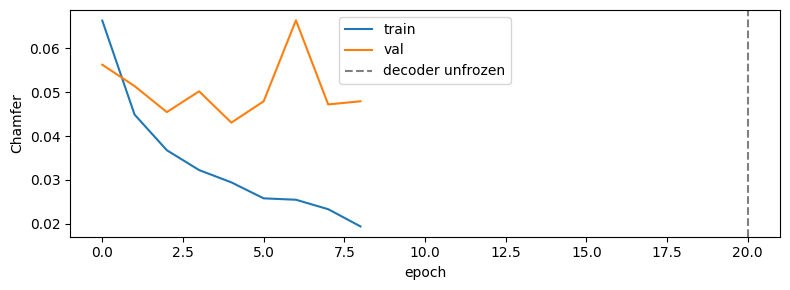

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(img_train_losses, label='train')
plt.plot(img_val_losses,   label='val')
plt.axvline(FREEZE_EPOCHS, color='gray', linestyle='--', label='decoder unfrozen')
plt.xlabel('epoch')
plt.ylabel('Chamfer')
plt.legend()
plt.tight_layout()
plt.show()

## 11  Visualise — image → predicted point cloud

epoch 5  val Chamfer 0.0431


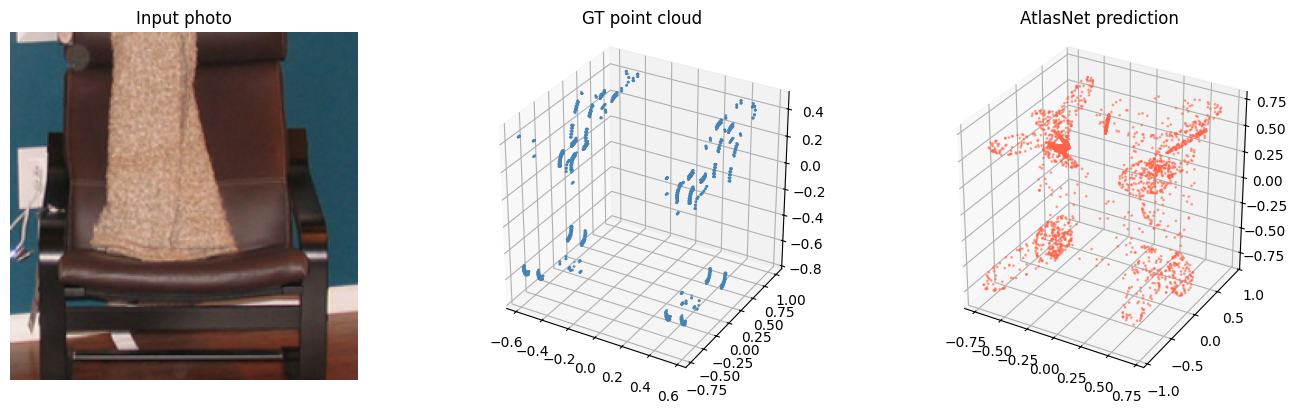

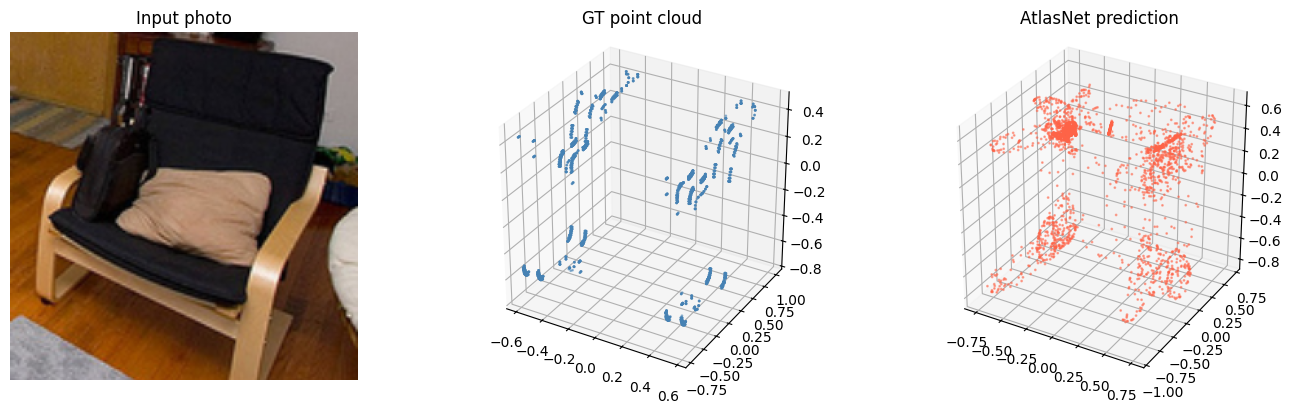

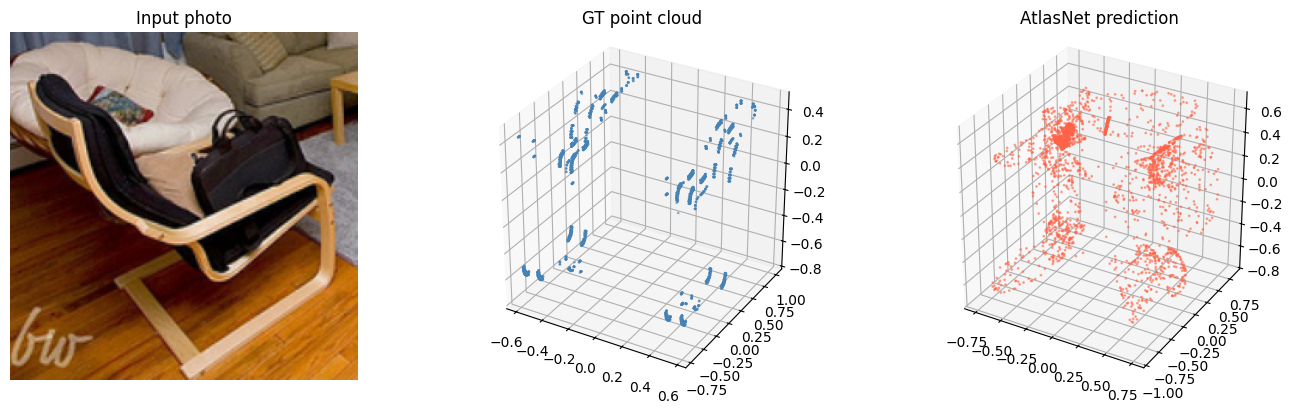

In [12]:
from mpl_toolkits.mplot3d import Axes3D   # noqa

img_ckpt = torch.load(IMG_SAVE_PATH, map_location=DEVICE, weights_only=True)
img_model.load_state_dict(img_ckpt['model'])
img_model.eval()
print(f"epoch {img_ckpt['epoch']}  val Chamfer {img_ckpt['val_loss']:.4f}")

imgs_batch, pts_gt_batch = next(iter(img_val_loader))
with torch.no_grad():
    pts_pred_batch = img_model(imgs_batch.to(DEVICE)).cpu()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

for i in range(min(3, len(imgs_batch))):
    fig = plt.figure(figsize=(14, 4))

    ax = fig.add_subplot(131)
    photo = (imgs_batch[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(photo)
    ax.set_title('Input photo')
    ax.axis('off')

    ax = fig.add_subplot(132, projection='3d')
    ax.scatter(*pts_gt_batch[i].T,   s=1, c='steelblue', alpha=0.5)
    ax.set_title('GT point cloud')
    ax.set_box_aspect([1,1,1])

    ax = fig.add_subplot(133, projection='3d')
    ax.scatter(*pts_pred_batch[i].T, s=1, c='tomato', alpha=0.5)
    ax.set_title('AtlasNet prediction')
    ax.set_box_aspect([1,1,1])

    plt.tight_layout()
    plt.show()